# Score-Based Generative Modeling through Stochastic Differential Equations (SDE)

In this tutorial, we will create and train an **unconditional Sub-Variance Preserving SDE** model ([Score-Based Generative Modeling through Stochastic Differential Equations (SDE)](https://arxiv.org/abs/2011.13456)) using the [TorchDiff](https://loqmansamani.github.io/torchdiff/) API, a diffusion library built on top of the [PyTorch](https://pytorch.org/) API.

All experiments in this tutorial were run on a consumer laptop with an Intel i5‑9300HF CPU and an NVIDIA GTX 1650 (4 GB VRAM). The code is designed to be lightweight so it can run on modest hardware, at the cost of longer training times and lower image resolution compared to large-scale DDPM setups. On GPUs with more memory, you can increase image resolution, model size, and batch size for better sample quality and faster convergence.


<br>
<div align="center">
  <img src="https://raw.githubusercontent.com/LoqmanSamani/TorchDiff/systembiology/imgs/sde.png" alt="UnCLIP overview" width="1200"/>
  <br>
  <em>An overview of the SDE pipeline, Song, Yang, et. al. (2020).</em>
  <br><br>
</div>

---

## Table of Contents

- [Data Preparation](#data-preparation)
- [Training a SDE Model](#training-a-sde-model)
- [Sampling from the Trained Model](#sampling-from-the-trained-model)

In [1]:
# import all necessary libraries and modules for training a SDE model
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets, transforms
import torchvision.utils as vutils
from torch.utils.data import DataLoader, Subset
# import required classes from the SDE module of TorchDiff
import torchdiff
from torchdiff.sde import SchedulerSDE, ForwardSDE, ReverseSDE, TrainSDE, SampleSDE
# import utility functions from the TorchDiff utils module
from torchdiff.utils import snr_capped_loss, DiffusionNetwork

In [2]:
print(torchdiff.__version__)

2.4.0


## Data Preparation

## Downloading the MNIST Dataset from Torchvision

For this tutorial we will use MNIST dataset from torchvision. here we download the [MNIST](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) dataset using the [Torchvision](https://pytorch.org/vision/stable/) library.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # For RGB
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

/home/loqman/Downloads/projs/TorchDiff/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [4]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

### Visualizing Training Images

In [5]:
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def denormalize(tensor):
    return tensor * 0.5 + 0.5

def visualize_cifar10_grid(dataloader, num_images=64):
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    all_images = images
    all_labels = labels
    
    while len(all_images) < num_images:
        try:
            images, labels = next(dataiter)
            all_images = torch.cat([all_images, images])
            all_labels = torch.cat([all_labels, labels])
        except StopIteration:
            break
    all_images = all_images[:num_images]
    all_labels = all_labels[:num_images]
    fig, axes = plt.subplots(8, 8, figsize=(6, 6))
    #fig.suptitle('CIFAR-10 Dataset Sample', fontsize=10, y=0.98)
    
    for i in range(8):
        for j in range(8):
            idx = i * 8 + j
            if idx < len(all_images):
                img = denormalize(all_images[idx])
                img = img.permute(1, 2, 0)
                img = torch.clamp(img, 0, 1)
                
                # Display image
                axes[i, j].imshow(img)
                axes[i, j].set_title(cifar10_classes[all_labels[idx]], fontsize=8, pad=2)
                axes[i, j].axis('off')
            else:
                axes[i, j].axis('off')
    plt.subplots_adjust(wspace=0.1, hspace=0.2, top=0.96, bottom=0.02, left=0.02, right=0.98)
    plt.show()

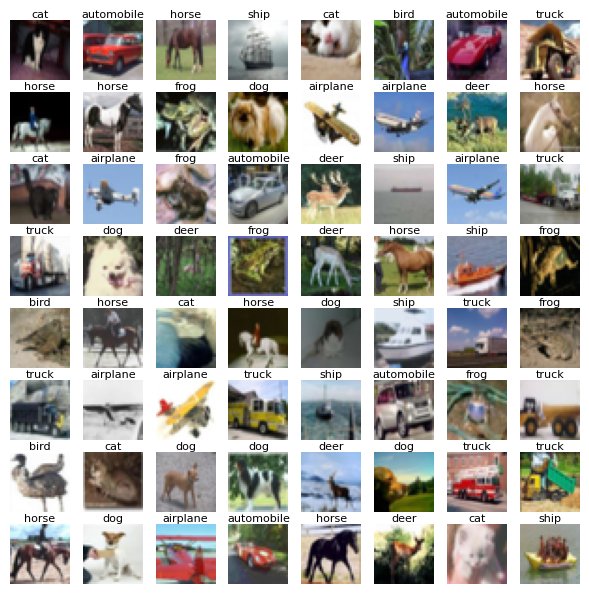

In [6]:
visualize_cifar10_grid(train_loader)

## Training Process for the SDE Model

Before training a SDE, we need to prepare several key components required for the training process:

- **DiffusionNetwork ([torchdiff.utils.DiffusionNetwork](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.DiffusionNetwork))**: this is the main network of all fundamental diffusion models (ddpm, ddim and sde) available in TorchDiff library, which is used as noise/score/v/x0 predictor.
 

- **Optimizer ([torch.optim.AdamW](https://pytorch.org/docs/stable/optim.html#torch.optim.AdamW))**:
  For training the DDPM model, we use the AdamW optimizer, which is well-suited for optimizing neural networks.

- **Loss Function ([MSE Loss](https://torchdiff.readthedocs.io/en/latest/utils.html#torchdiff.utils.mse_loss))**: here we use internal mse loss of TorchDiff.

In [7]:
# initialize the noise predictor network (here we have two options: score or noise to predict.
#we use noise which is conventional and more stable compare to predict score) for the SDE model
diff_net = DiffusionNetwork(
    in_channels = 3, 
    down_channels = [128, 256, 512],
    mid_channels = [512, 512], 
    up_channels = [512, 256, 128],
    down_sampling = [True, True],
    time_embed_dim = 512,
    y_embed_dim = 512,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = True, # continuous time is used for SDE based models (it rescales time)
    use_flash_attention = True # if true automatically uses flash attention if available 
).to('cuda')

optim = torch.optim.AdamW(
    [p for p in diff_net.parameters()], lr=1e-4
)

In [8]:
print(sum(p.numel() for p in diff_net.parameters())) # this is actually a relatively big model

33773571


### Required TorchDiff SDE Classes for Training and Sampling

To train  and sample from the trined model, here we need the following specific classes from the TorchDiff SDE module:

- **sde Variance Scheduler ([SchedulerSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.SchedulerSDE))**:
  This class manages the noise schedule for the SDE model.

- **Forward Diffusion ([ForwardSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ForwardSDE))**: forward diffusion class of ddpm model applies forward ddpm process and is used during training. 

- **Reverse Diffusion ([ReverseSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.ReverseSDE))**:
  This class is used during the sampling process to perform reverse diffusion. 

- **SDE Trainer ([TrainSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.TrainSDE))**:
  This class handles the training of the prepared SDE model.


- **SDE Sampler ([SampleSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.SampleSDE))**:
  This class handles sampling process. it uses trained model and generates samples.  

In [9]:
vs = SchedulerSDE("cosine") # or cosine

# set up the forward and reverse diffusion processes
fwd = ForwardSDE(vs, 'sub-vp', 'noise')  
rev = ReverseSDE(vs, 'sub-vp', 'noise')

# configure the SDE trainer for model training
trainer = TrainSDE(
    score_net = diff_net,
    fwd_sde = fwd,
    rwd_sde = rev,
    optim = optim,
    loss_fn = snr_capped_loss,
    train_loader = train_loader,
    max_epochs = 200,
    device = 'cuda',
    grad_acc = 4,
    log_freq = 1,
    warmup_steps = 10000,
)

In [12]:
# start trining
#losses = trainer()

## Sampling Process for the SDE Model

After training the SDE model, we can generate new images. While we can directly use the trained model, it is common to load the trained parameters of the denoising model and generate new data using the [torchdiff.sde.SampleSDE](https://torchdiff.readthedocs.io/en/latest/sde.html#torchdiff.sde.SampleSDE) class. In this tutorial, we will load the trained parameters and generate new images.

In [11]:
# load the trained model
c = torch.load('best_model_epoch_56.pth', map_location = 'cpu')
print(c.keys())

dict_keys(['epoch', 'model_state_dict_score_net', 'model_state_dict_cond', 'optim_state_dict', 'loss', 'losses', 'scheduler_model', 'max_epochs'])


In [14]:
diff_net_ = DiffusionNetwork(
    in_channels = 3, 
    down_channels = [128, 256, 512],
    mid_channels = [512, 512], 
    up_channels = [512, 256, 128],
    down_sampling = [True, True],
    time_embed_dim = 512,
    y_embed_dim = 512,
    num_down_blocks = 2,
    num_mid_blocks =  2,
    num_up_blocks = 2,
    down_sampling_factor = 2,
    cont_time = True, # continuous time is used for SDE based models (it rescales time)
    use_flash_attention = True # if true automatically uses flash attention if available 
).to('cuda')

vs_ = SchedulerSDE("cosine")
rev_ = ReverseSDE(vs_, 'sub-vp', 'noise')

diff_net_.load_state_dict(c['model_state_dict_score_net'])
diff_net_.eval()

rev_.vs.load_state_dict(c['scheduler_model'])

<All keys matched successfully>

In [19]:
# sampling process
sampler = SampleSDE(
    rwd_sde = rev_,
    score_net = diff_net_,
    img_size = (32, 32),
    batch_size = 50, # generates 100 images
    in_channels = 3, # one channel because the model is trained on a grayscale dataset
    device="cuda",
    norm_range = (-1, 1)
)

In [20]:
imgs = sampler(num_steps = 400) # here we use 1000 steps to generate samples 

Sampling: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 400/400 [01:56<00:00,  3.43it/s]


### Visualizing Generated Images

In [21]:
def denormalize(tensor):
    return tensor * 0.5 + 0.5

def visualize_(
    image_dir,
    num_images=64,
    image_size=32,
    normalize=True
):
    image_files = [
        f for f in os.listdir(image_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ][:num_images]
    transform_list = [
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ]
    if normalize:
        transform_list.append(
            transforms.Normalize((0.5, 0.5, 0.5),
                                 (0.5, 0.5, 0.5))
        )
    transform = transforms.Compose(transform_list)
    images = []
    for img_file in image_files:
        img_path = os.path.join(image_dir, img_file)
        img = Image.open(img_path).convert("RGB")
        images.append(transform(img))

    images = torch.stack(images)
    fig, axes = plt.subplots(10, 10, figsize=(8, 8))
    for i in range(10):
        for j in range(10):
            idx = i * 10 + j
            axes[i, j].axis("off")

            if idx < len(images):
                img = images[idx]
                if normalize:
                    img = denormalize(img)
                img = img.permute(1, 2, 0)
                img = torch.clamp(img, 0, 1)
                axes[i, j].imshow(img)

    plt.subplots_adjust(
        wspace=0.05, hspace=0.05,
        top=0.98, bottom=0.02,
        left=0.02, right=0.98
    )
    plt.show()

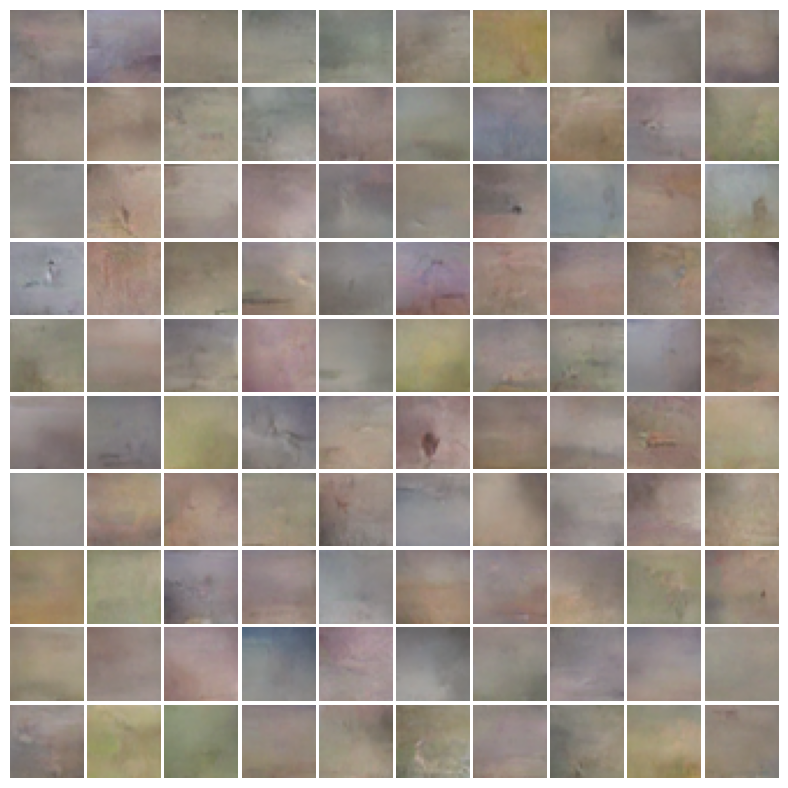

In [23]:
visualize_(image_dir = "sde_samples", num_images=100, normalize = True)

### Evaluating the Generated Images

Not so bad! but i think it is in the right direction and with a little more effort and tuning techniques it can be better than this and we can accept it as a light weight MNIST diffusion model.
keep in mind that you can get almost the same result when you use a smaller network (something like 2-million-parameter model will do the same, so no need to keep it this heavy).

## Useful Resources

The following links provide additional information and resources for working with the TorchDiff library:

- [TorchDiff Webpage](https://loqmansamani.github.io/torchdiff/): The official webpage for the TorchDiff library.
- [TorchDiff GitHub Repository](https://github.com/loqmansamani/torchdiff): The source code and documentation for TorchDiff.
- [TorchDiff API Documentation](https://torchdiff.readthedocs.io/en/latest/index.html): The official API reference for TorchDiff.
- [Score-Based Generative Modeling with SDEs: Theory and Implementation in TorchDiff](https://medium.com/@samaniloqman91/score-based-generative-modeling-with-sdes-theory-and-implementation-in-torchdiff-db9a20a84978)
- [Score-Based Generative Modeling through Stochastic Differential Equations](https://arxiv.org/abs/2011.13456)